In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import os

# Check if the file exists, if not, prompt for upload
file_path = '/content/Bioactive (1).xlsx' # Updated file path
if not os.path.exists(file_path):
    uploaded = files.upload()
    if 'Bioactive (1).xlsx' in uploaded:
        print('Bioactive (1).xlsx uploaded successfully.')
    else:
        print('Bioactive (1).xlsx not found after upload. Please ensure you upload the correct file.')
        # Exit or handle the error appropriately if the file is critical

# Load dataset
df = pd.read_excel(file_path)

# Preview
df.head()

Saving Bioactive.xlsx to Bioactive (1).xlsx
Bioactive (1).xlsx uploaded successfully.


,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,LogGI50_M,LogGI50_u,LogGI50_V,IndnGI50,StddevGI50,LogTGI_M,LogTGI_u,LogTGI_V,IndnTGI,StddevTGI
0,RESULT_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FLOAT,FLOAT,FLOAT,INTEGER,FLOAT,FLOAT,FLOAT,FLOAT,INTEGER,FLOAT
1,RESULT_DESCR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Log of the GI50 result, unit: M.","Log of the GI50 result, unit: ug/mL.","Log of the GI50 result, unit: Volumetric.",Number of tests averaged for the GI50 value fo...,Standard Deviation of the Log10 of the GI50 re...,"Log of the TGI result, unit: M.","Log of the TGI result, unit: ug/mL.","Log of the TGI result, unit: Volumetric.",Number of tests averaged for the TGI value for...,Standard Deviation of the Log10 of the TGI res...
2,1,66954.0,11122.0,CC1=CC(=O)C=CC1=O,Inactive,10.0,http://dtp.nci.nih.gov/dtpstandard/servlet/dos...,NaN,-4.5753,NaN,NaN,1,0,-4,NaN,NaN,1,0
3,2,66954.0,11122.0,CC1=CC(=O)C=CC1=O,Inactive,11.0,http://dtp.nci.nih.gov/dtpstandard/servlet/dos...,NaN,-4.6886,NaN,NaN,2,0.03,-4.2218,NaN,NaN,2,0.0553
4,3,66970.0,219123.0,CCCCCCCCCCCCCCCC1=C(C=CC(=C1)O)N,Inactive,0.0,http://dtp.nci.nih.gov/dtpstandard/servlet/dos...,NaN,-4.0169,NaN,NaN,3,0.0216,-4,NaN,NaN,3,0


In [ ]:

df = df.iloc[2:].reset_index(drop=True) # Remove metadata rows

print(df.shape)
# Check dataset shape

df.head() # Preview cleaned data

(58219, 18)


,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,LogGI50_M,LogGI50_u,LogGI50_V,IndnGI50,StddevGI50,LogTGI_M,LogTGI_u,LogTGI_V,IndnTGI,StddevTGI
0,1,66954.0,11122.0,CC1=CC(=O)C=CC1=O,Inactive,10.0,http://dtp.nci.nih.gov/dtpstandard/servlet/dos...,NaN,-4.5753,NaN,NaN,1,0,-4,NaN,NaN,1,0
1,2,66954.0,11122.0,CC1=CC(=O)C=CC1=O,Inactive,11.0,http://dtp.nci.nih.gov/dtpstandard/servlet/dos...,NaN,-4.6886,NaN,NaN,2,0.03,-4.2218,NaN,NaN,2,0.0553
2,3,66970.0,219123.0,CCCCCCCCCCCCCCCC1=C(C=CC(=C1)O)N,Inactive,0.0,http://dtp.nci.nih.gov/dtpstandard/servlet/dos...,NaN,-4.0169,NaN,NaN,3,0.0216,-4,NaN,NaN,3,0
3,4,66977.0,219128.0,C1=CC=C(C=C1)C(CCI)(C2=CC=CC=C2)C3=CC=CC=C3,Inactive,15.0,http://dtp.nci.nih.gov/dtpstandard/servlet/dos...,NaN,-4.8729,NaN,NaN,1,0,-4.5084,NaN,NaN,1,0
4,5,538184.0,92844.0,CN(C)CCC(=O)C1=CC=CC=C1.Cl,Inactive,3.0,http://dtp.nci.nih.gov/dtpstandard/servlet/dos...,NaN,-4.2086,NaN,NaN,3,0.3613,-4.1307,NaN,NaN,3,0.2263


In [ ]:
df.info() # Dataset information

df.isnull().sum() # Missing values count

df.describe(include='all') # Statistical summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58219 entries, 0 to 58218
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PUBCHEM_RESULT_TAG             58219 non-null  object 
 1   PUBCHEM_SID                    58219 non-null  float64
 2   PUBCHEM_CID                    56825 non-null  float64
 3   PUBCHEM_EXT_DATASOURCE_SMILES  56825 non-null  object 
 4   PUBCHEM_ACTIVITY_OUTCOME       58219 non-null  object 
 5   PUBCHEM_ACTIVITY_SCORE         58219 non-null  float64
 6   PUBCHEM_ACTIVITY_URL           58219 non-null  object 
 7   PUBCHEM_ASSAYDATA_COMMENT      0 non-null      float64
 8   LogGI50_M                      57689 non-null  object 
 9   LogGI50_u                      480 non-null    object 
 10  LogGI50_V                      50 non-null     object 
 11  IndnGI50                       58219 non-null  object 
 12  StddevGI50                     58219 non-null 

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,LogGI50_M,LogGI50_u,LogGI50_V,IndnGI50,StddevGI50,LogTGI_M,LogTGI_u,LogTGI_V,IndnTGI,StddevTGI
count,58219.0,5.821900e+04,5.682500e+04,56825,58219,58219.000000,58219,0.0,57689.0,480.0000,50.000,58219.0,58219.0,57689.0,480.0000,50.000,58219.0,58219.0
unique,58219.0,NaN,NaN,54943,2,NaN,56978,NaN,19141.0,276.0000,9.000,45.0,4635.0,13458.0,228.0000,8.000,45.0,4569.0
top,58219.0,NaN,NaN,C[C@H]1[C@@H](C(=O)N[C@@H](C(=O)N2CCC[C@H]2C(=...,Inactive,NaN,http://dtp.nci.nih.gov/dtpstandard/servlet/dos...,NaN,-4.0,2.1761,0.301,1.0,0.0,-4.0,2.1761,0.301,1.0,0.0
freq,1.0,NaN,NaN,8,54178,NaN,8,NaN,20807.0,57.0000,34.000,45823.0,47574.0,31260.0,87.0000,34.000,45823.0,49822.0
mean,NaN,7.409081e+07,2.763417e+07,NaN,NaN,12.586218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,1.630301e+08,5.240470e+07,NaN,NaN,16.162997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,6.695400e+04,5.100000e+01,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,4.999330e+05,3.745160e+05,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,5.179790e+05,4.014200e+05,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,5.623210e+05,1.859061e+07,NaN,NaN,21.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
numeric_cols = [
    'PUBCHEM_ACTIVITY_SCORE',
    'LogGI50_M',
    'IndnGI50',
    'StddevGI50',
    'LogTGI_M',
    'IndnTGI',
    'StddevTGI'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Verify conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58219 entries, 0 to 58218
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PUBCHEM_RESULT_TAG             58219 non-null  object 
 1   PUBCHEM_SID                    58219 non-null  float64
 2   PUBCHEM_CID                    56825 non-null  float64
 3   PUBCHEM_EXT_DATASOURCE_SMILES  56825 non-null  object 
 4   PUBCHEM_ACTIVITY_OUTCOME       58219 non-null  object 
 5   PUBCHEM_ACTIVITY_SCORE         58219 non-null  float64
 6   PUBCHEM_ACTIVITY_URL           58219 non-null  object 
 7   PUBCHEM_ASSAYDATA_COMMENT      0 non-null      float64
 8   LogGI50_M                      57689 non-null  float64
 9   LogGI50_u                      480 non-null    object 
 10  LogGI50_V                      50 non-null     object 
 11  IndnGI50                       58219 non-null  int64  
 12  StddevGI50                     58219 non-null 

In [ ]:
# Drop unnecessary columns
df.drop(columns=[
    'PUBCHEM_ACTIVITY_URL',
    'PUBCHEM_ASSAYDATA_COMMENT'
], inplace=True)

# Preview dataset
df.head()

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,LogGI50_M,LogGI50_u,LogGI50_V,IndnGI50,StddevGI50,LogTGI_M,LogTGI_u,LogTGI_V,IndnTGI,StddevTGI
0,1,66954.0,11122.0,CC1=CC(=O)C=CC1=O,Inactive,10.0,-4.5753,NaN,NaN,1,0.0000,-4.0000,NaN,NaN,1,0.0000
1,2,66954.0,11122.0,CC1=CC(=O)C=CC1=O,Inactive,11.0,-4.6886,NaN,NaN,2,0.0300,-4.2218,NaN,NaN,2,0.0553
2,3,66970.0,219123.0,CCCCCCCCCCCCCCCC1=C(C=CC(=C1)O)N,Inactive,0.0,-4.0169,NaN,NaN,3,0.0216,-4.0000,NaN,NaN,3,0.0000
3,4,66977.0,219128.0,C1=CC=C(C=C1)C(CCI)(C2=CC=CC=C2)C3=CC=CC=C3,Inactive,15.0,-4.8729,NaN,NaN,1,0.0000,-4.5084,NaN,NaN,1,0.0000
4,5,538184.0,92844.0,CN(C)CCC(=O)C1=CC=CC=C1.Cl,Inactive,3.0,-4.2086,NaN,NaN,3,0.3613,-4.1307,NaN,NaN,3,0.2263


irrelevant metadata columns were removed to improve dataset quality and reduce unnecessary noise during analysis.

In [ ]:
# Check duplicated rows
duplicates = df.duplicated().sum()

print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Check new shape
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (58219, 16)


In [ ]:
# Missing values percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

# Sort descending
missing_percent.sort_values(ascending=False)


,0
LogTGI_V,99.914117
LogGI50_V,99.914117
LogGI50_u,99.175527
LogTGI_u,99.175527
PUBCHEM_CID,2.394407
PUBCHEM_EXT_DATASOURCE_SMILES,2.394407
LogTGI_M,0.910356
LogGI50_M,0.910356
PUBCHEM_ACTIVITY_OUTCOME,0.000000
PUBCHEM_ACTIVITY_SCORE,0.000000


Several columns contain substantial missing values. Columns with extremely high missingness may not contribute meaningful information and can be removed.

In [ ]:
# Drop highly missing columns
df.drop(columns=[
    'LogGI50_u',
    'LogGI50_V',
    'LogTGI_u',
    'LogTGI_V'
], inplace=True)

# Check remaining columns
df.columns

Index(['PUBCHEM_RESULT_TAG', 'PUBCHEM_SID', 'PUBCHEM_CID',
       'PUBCHEM_EXT_DATASOURCE_SMILES', 'PUBCHEM_ACTIVITY_OUTCOME',
       'PUBCHEM_ACTIVITY_SCORE', 'LogGI50_M', 'IndnGI50', 'StddevGI50',
       'LogTGI_M', 'IndnTGI', 'StddevTGI'],
      dtype='object')

In [ ]:
df[col] = df[col].fillna(df[col].median())

Missing numerical values were handled successfully using median imputation, reducing the impact of outliers and preserving dataset size.

In [ ]:
# Remove rows with missing SMILES
df = df.dropna(subset=['PUBCHEM_EXT_DATASOURCE_SMILES'])

# Check dataset shape
print(df.shape)

(56825, 12)


Rows lacking molecular structure information were removed because SMILES strings are critical for molecular descriptor generation.

In [ ]:
# Target distribution
df['PUBCHEM_ACTIVITY_OUTCOME'].value_counts()

,count
PUBCHEM_ACTIVITY_OUTCOME,
Inactive,52929
Active,3896


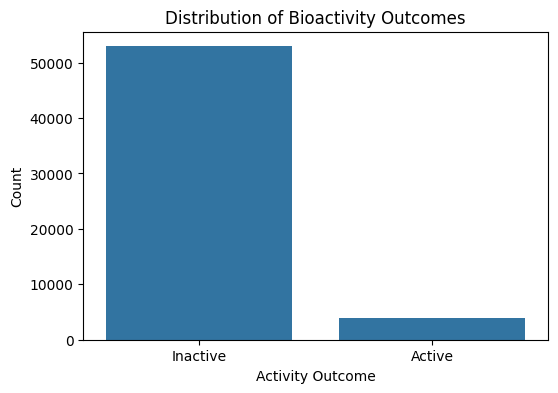

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target distribution
plt.figure(figsize=(6,4))

sns.countplot(x='PUBCHEM_ACTIVITY_OUTCOME', data=df)

plt.title("Distribution of Bioactivity Outcomes")
plt.xlabel("Activity Outcome")
plt.ylabel("Count")

plt.show()

The visualization shows the frequency of active and inactive compounds within the dataset. Understanding class distribution is important for selecting evaluation metrics and handling imbalance.

In [ ]:
# Summary statistics
df.describe()

,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_ACTIVITY_SCORE,LogGI50_M,IndnGI50,StddevGI50,LogTGI_M,IndnTGI,StddevTGI
count,5.682500e+04,5.682500e+04,56825.000000,56825.000000,56825.000000,56825.000000,56825.000000,56825.000000,56825.000000
mean,7.490848e+07,2.763417e+07,12.566265,-4.782213,1.409820,0.040743,-4.391408,1.409820,0.040721
std,1.637832e+08,5.240470e+07,16.079855,0.974038,12.991734,0.141572,0.688271,12.991734,0.163295
min,6.695400e+04,5.100000e+01,0.000000,-13.602100,1.000000,0.000000,-13.602100,1.000000,0.000000
25%,5.001080e+05,3.745160e+05,0.000000,-5.269600,1.000000,0.000000,-4.602100,1.000000,0.000000
50%,5.180030e+05,4.014200e+05,7.000000,-4.540000,1.000000,0.000000,-4.000000,1.000000,0.000000
75%,5.557740e+05,1.859061e+07,21.000000,-4.000000,1.000000,0.000000,-4.000000,1.000000,0.000000
max,5.227926e+08,1.778082e+08,100.000000,4.000000,2495.000000,2.828400,4.000000,2495.000000,2.828400


The dataset contains several continuous bioactivity measurements such as GI50 and TGI values. These variables exhibit variability typical of pharmacological assay data.

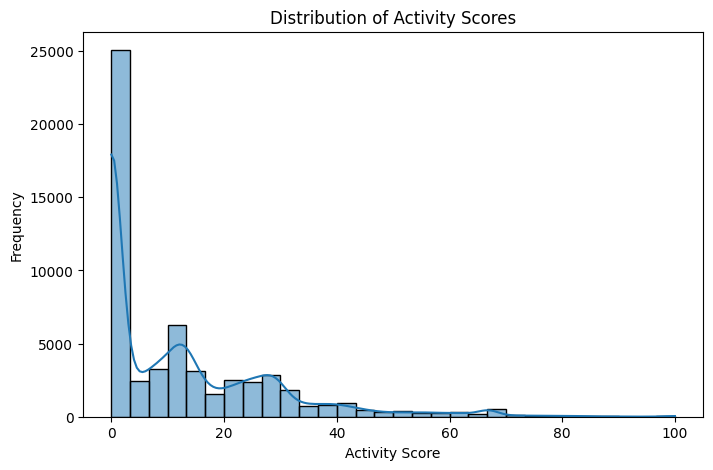

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['PUBCHEM_ACTIVITY_SCORE'], bins=30, kde=True)

plt.title("Distribution of Activity Scores")
plt.xlabel("Activity Score")
plt.ylabel("Frequency")

plt.show()

The activity score distribution provides insight into the potency and biological response patterns of screened compounds.

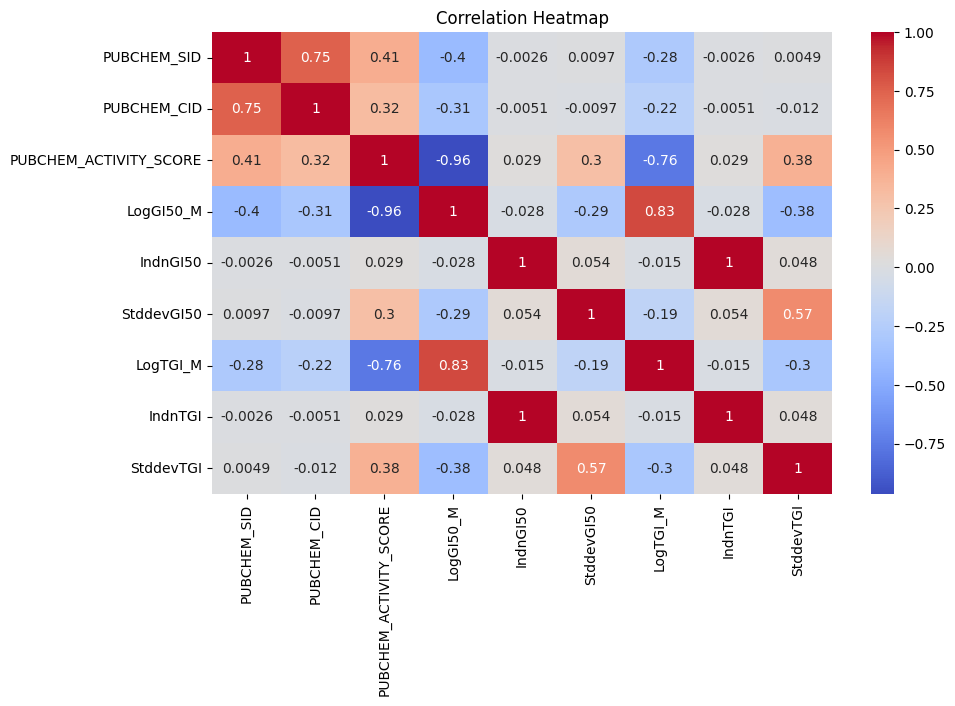

In [ ]:
# Correlation matrix
corr = df.select_dtypes(include=['float64', 'int64']).corr()

# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

The heatmap reveals relationships between bioactivity-related measurements such as GI50, TGI, and activity scores. Strong correlations may indicate biologically related assay behavior

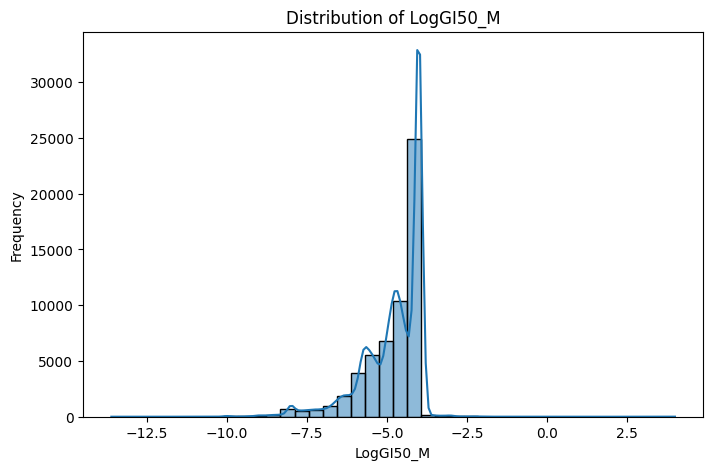

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['LogGI50_M'], bins=40, kde=True)

plt.title("Distribution of LogGI50_M")
plt.xlabel("LogGI50_M")
plt.ylabel("Frequency")

plt.show()

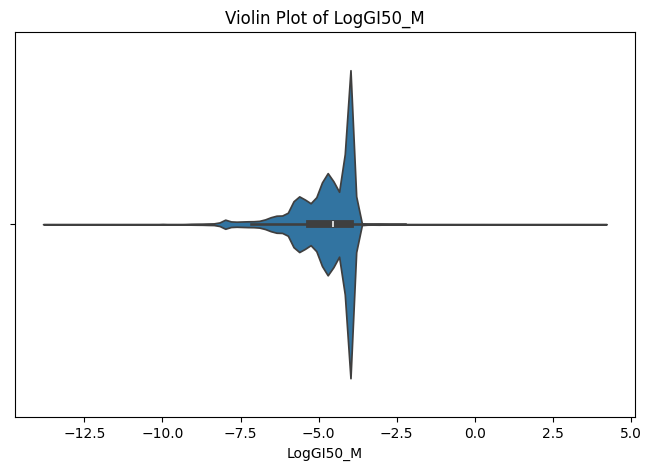

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(x=df['LogGI50_M'])

plt.title("Violin Plot of LogGI50_M")

plt.show()

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 49.0 MB/s eta 0:00:00


RDKit is a cheminformatics library used to compute molecular descriptors from chemical structures.

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski

import pandas as pd
import numpy as np

In [ ]:
# Convert SMILES to molecule objects
df['Molecule'] = df['PUBCHEM_EXT_DATASOURCE_SMILES'].apply(Chem.MolFromSmiles)

# Check conversion
df[['PUBCHEM_EXT_DATASOURCE_SMILES', 'Molecule']].head()

[10:21:05] WARNING: not removing hydrogen atom without neighbors
[10:21:09] WARNING: not removing hydrogen atom without neighbors


,PUBCHEM_EXT_DATASOURCE_SMILES,Molecule
0,CC1=CC(=O)C=CC1=O,<rdkit.Chem.rdchem.Mol object at 0x7e97c9027760>
1,CC1=CC(=O)C=CC1=O,<rdkit.Chem.rdchem.Mol object at 0x7e97c9027920>
2,CCCCCCCCCCCCCCCC1=C(C=CC(=C1)O)N,<rdkit.Chem.rdchem.Mol object at 0x7e97c9027990>
3,C1=CC=C(C=C1)C(CCI)(C2=CC=CC=C2)C3=CC=CC=C3,<rdkit.Chem.rdchem.Mol object at 0x7e97c9027a00>
4,CN(C)CCC(=O)C1=CC=CC=C1.Cl,<rdkit.Chem.rdchem.Mol object at 0x7e97c9027a70>


In [ ]:
# Remove invalid molecules
df = df[df['Molecule'].notnull()]

# Check dataset shape
print(df.shape)

(56825, 13)


Rows containing invalid molecular structures were removed to maintain data quality during feature engineering.

In [ ]:
# Molecular weight
df['MolWt'] = df['Molecule'].apply(Descriptors.MolWt)

# LogP (hydrophobicity)
df['LogP'] = df['Molecule'].apply(Descriptors.MolLogP)

# Number of hydrogen bond donors
df['NumHDonors'] = df['Molecule'].apply(Lipinski.NumHDonors)

# Number of hydrogen bond acceptors
df['NumHAcceptors'] = df['Molecule'].apply(Lipinski.NumHAcceptors)

# Topological Polar Surface Area
df['TPSA'] = df['Molecule'].apply(Descriptors.TPSA)

In [ ]:
df[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA']].head()


,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA
0,122.123,0.6407,0,2,34.14
1,122.123,0.6407,0,2,34.14
2,319.533,6.6081,2,2,46.25
3,398.287,5.8461,0,0,0.00
4,213.708,2.2428,0,2,20.31


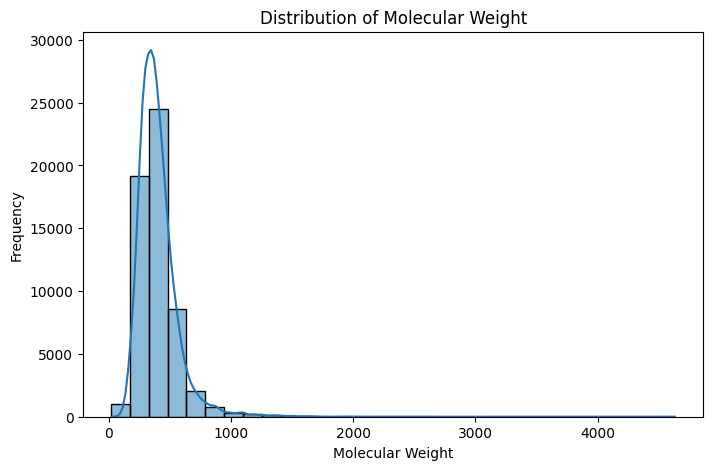

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['MolWt'], bins=30, kde=True)

plt.title("Distribution of Molecular Weight")
plt.xlabel("Molecular Weight")
plt.ylabel("Frequency")

plt.show()

The molecular weight distribution provides insight into the chemical diversity of the screened compounds.

In [ ]:
# df['LogP'] = ...

In [ ]:
# Check LogP range
print(df['LogP'].describe())

count    56825.000000
mean         3.339513
std          2.373036
min        -14.986800
25%          1.997020
50%          3.384900
75%          4.714720
max         41.844400
Name: LogP, dtype: float64


In [ ]:
# Keep realistic LogP values only
df = df[(df['LogP'] >= -5) & (df['LogP'] <= 8)]

# Check dataset shape
print(df.shape)

(55462, 18)


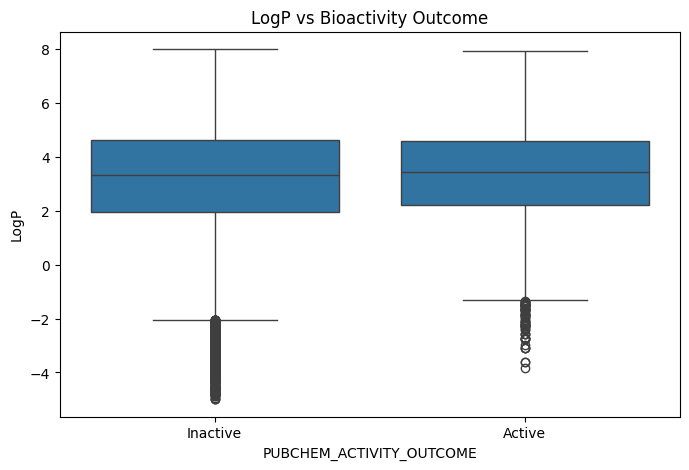

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='PUBCHEM_ACTIVITY_OUTCOME',
    y='LogP',
    data=df
)

plt.title("LogP vs Bioactivity Outcome")

plt.show()

The visualization helps assess whether compound hydrophobicity differs between active and inactive compounds.

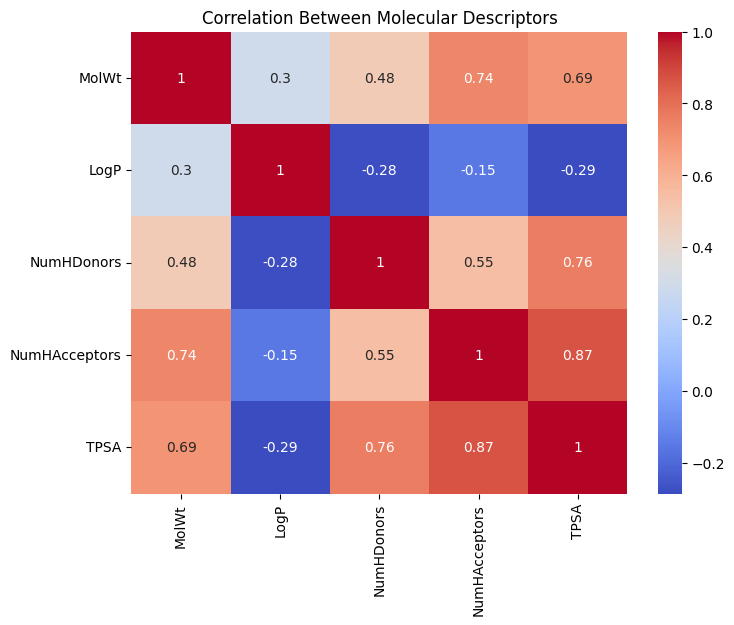

In [ ]:
descriptor_cols = [
    'MolWt',
    'LogP',
    'NumHDonors',
    'NumHAcceptors',
    'TPSA'
]

corr = df[descriptor_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Between Molecular Descriptors")

plt.show()

The heatmap reveals relationships between molecular properties, which may influence compound bioactivity.

In [ ]:
# Encode target variable
df['Target'] = df['PUBCHEM_ACTIVITY_OUTCOME'].map({
    'Active': 1,
    'Inactive': 0
})

# Check distribution
df['Target'].value_counts()

,count
Target,
0,51641
1,3821


the target variable was successfully encoded into binary format for easier classification modeling.

In [ ]:
features = [
    'MolWt',
    'LogP',
    'NumHDonors',
    'NumHAcceptors',
    'TPSA'
]

# Input features
X = df[features]

# Target variable
y = df['Target']

# Check shapes
print(X.shape)
print(y.shape)

(55462, 5)
(55462,)


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

# Select top features
selector = SelectKBest(score_func=f_classif, k=8)

X_selected = selector.fit_transform(X, y)

# Selected feature names
selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA'], dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=8 is greater than n_features=5. All the features will be returned.
  warnings.warn(


Feature selection identified the most statistically informative variables associated with compound bioactivity prediction.

In [ ]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(44369, 5)
(11093, 5)


The dataset was split into training and testing subsets while preserving class distribution through stratification.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize model
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train_scaled, y_train)

# Accuracy
lr_score = lr_model.score(X_test_scaled, y_test)

print("Logistic Regression Accuracy:", lr_score)

Logistic Regression Accuracy: 0.928964211665014


Logistic Regression serves as a baseline linear classification model for predicting compound bioactivity with accuracy of 92%

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Accuracy
rf_score = rf_model.score(X_test, y_test)

print("Random Forest Accuracy:", rf_score)

Random Forest Accuracy: 0.9455512485351122


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

# Initialize model
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Accuracy
xgb_score = xgb_model.score(X_test, y_test)

print("XGBoost Accuracy:", xgb_score)

XGBoost Accuracy: 0.9346434688542324


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize model
knn_model = KNeighborsClassifier()

# Train
knn_model.fit(X_train_scaled, y_train)

# Accuracy
knn_score = knn_model.score(X_test_scaled, y_test)

print("KNN Accuracy:", knn_score)

KNN Accuracy: 0.9308572973947534


KNN classifies compounds according to neighboring compounds with similar molecular properties.

In [ ]:
from sklearn.svm import SVC

# Initialize model
svm_model = SVC()

# Train
svm_model.fit(X_train_scaled, y_train)

# Accuracy
svm_score = svm_model.score(X_test_scaled, y_test)

print("SVM Accuracy:", svm_score)

SVM Accuracy: 0.9329306770035157


In [ ]:
models = [
    'Logistic Regression',
    'Random Forest',
    'XGBoost',
    'SVM',
    'KNN'
]

scores = [
    lr_score,
    rf_score,
    xgb_score,
    svm_score,
    knn_score
]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': scores
})

# Sort by best accuracy
comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

comparison_df

,Model,Accuracy
1,Random Forest,0.945551
2,XGBoost,0.934643
3,SVM,0.932931
4,KNN,0.930857
0,Logistic Regression,0.928964


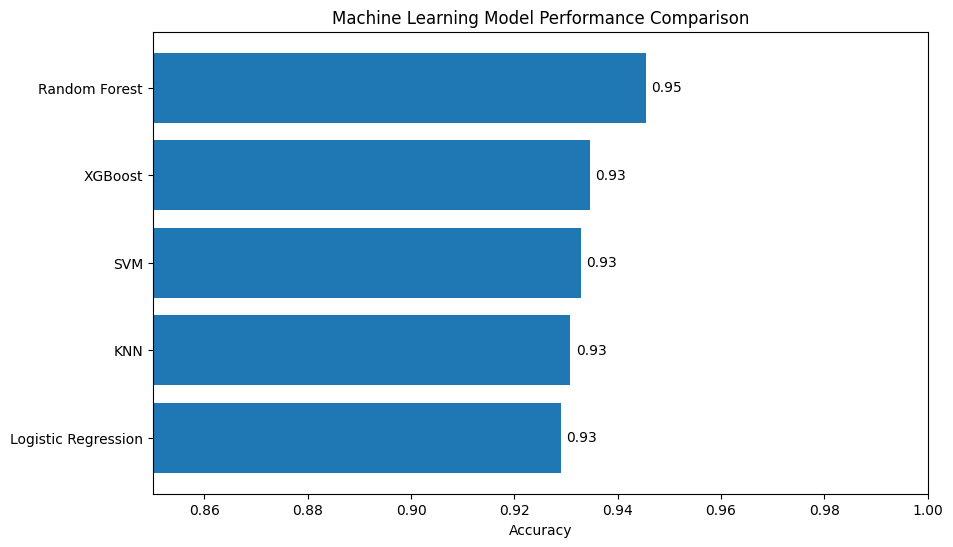

In [ ]:
# Sort models by accuracy
comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=True
)

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    comparison_df['Model'],
    comparison_df['Accuracy']
)

# Add accuracy labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center'
    )

plt.xlabel("Accuracy")
plt.title("Machine Learning Model Performance Comparison")

plt.xlim(0.85, 1.0)

plt.show()

The horizontal comparison plot demonstrates that multiple machine learning algorithms achieved similarly strong predictive performance, indicating robust relationships between molecular descriptors and compound bioactivity.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# Logistic Regression predictions
lr_pred = lr_model.predict(X_test_scaled)

# Random Forest predictions
rf_pred = rf_model.predict(X_test)

# XGBoost predictions
xgb_pred = xgb_model.predict(X_test)

# SVM predictions
svm_pred = svm_model.predict(X_test_scaled)

# KNN predictions
knn_pred = knn_model.predict(X_test_scaled)

In [ ]:
evaluation_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'SVM',
        'KNN'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, knn_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, knn_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, knn_pred)
    ],

    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, knn_pred)
    ]
})

# Sort by F1-score
evaluation_df = evaluation_df.sort_values(
    by='F1-Score',
    ascending=False
)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.945551,0.735294,0.327225,0.452899
4,KNN,0.930857,0.495268,0.205497,0.290472
2,XGBoost,0.934643,0.638298,0.117801,0.198895
3,SVM,0.932931,0.661290,0.053665,0.099274
0,Logistic Regression,0.928964,0.306452,0.024869,0.046005


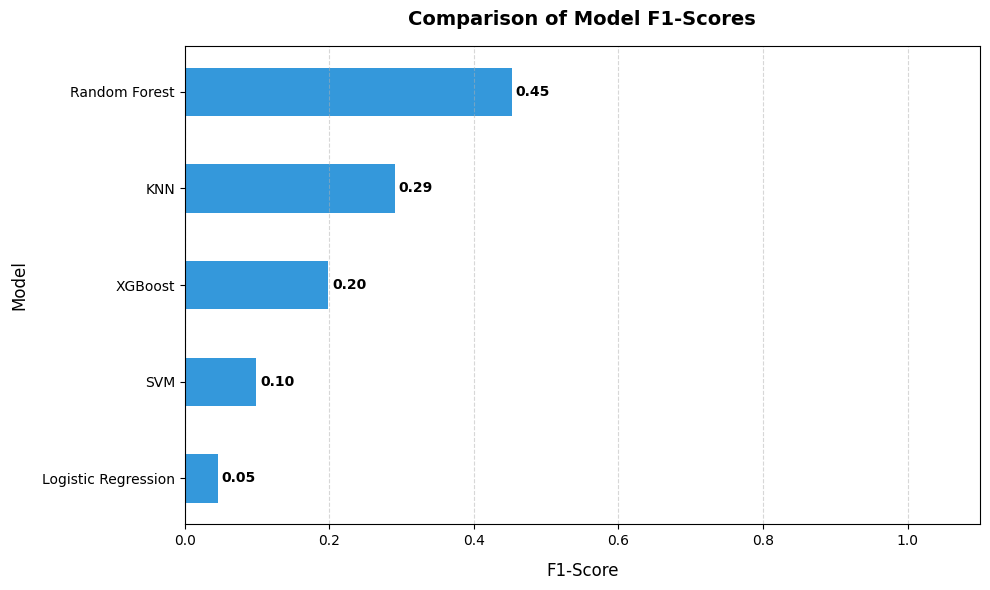

In [ ]:
import matplotlib.pyplot as plt

# 1. Standardize figure size (10 wide, 6 high is plenty for a few bars)
plt.figure(figsize=(10, 6))

# 2. Make sure evaluation_df is sorted for a cleaner presentation
df_sorted = evaluation_df.sort_values(by='F1-Score', ascending=True)

bars = plt.barh(
    df_sorted['Model'],
    df_sorted['F1-Score'],
    color='#3498db',          # A nice clean blue
    height=0.5
)

# Add labels dynamically based on the actual bar width
for bar in bars:
    width = bar.get_width()

    # Only draw text if the width falls within a reasonable range to prevent breaking the layout
    if width > 0:
        plt.text(
            width + 0.005,                            # Tiny padding to the right of the bar end
            bar.get_y() + bar.get_height() / 2,
            f'{width:.2f}',                           # Formats to 2 decimal places
            va='center',
            ha='left',
            fontsize=10,
            weight='bold'
        )

# 3. Structural layout adjustments
plt.xlabel("F1-Score", fontsize=12, labelpad=10)
plt.ylabel("Model", fontsize=12, labelpad=10)
plt.title("Comparison of Model F1-Scores", fontsize=14, weight='bold', pad=15)

# Tighten the x-axis limits around the actual data range (0.0 to 1.1 ensures safety)
# If ALL your F1 scores are above 0.85, change this back to (0.85, 1.05)
plt.xlim(0.0, 1.1)

plt.grid(axis='x', linestyle='--', alpha=0.5) # Adds clean gridlines behind bars
plt.tight_layout()

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Change this in your notebook
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample',  # Forces trees to pay attention to Class 1
    random_state=42
)

# Retrain and run the report again
rf_model.fit(X_train, y_train)
best_pred = rf_model.predict(X_test)
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10329
           1       0.70      0.35      0.47       764

    accuracy                           0.95     11093
   macro avg       0.83      0.67      0.72     11093
weighted avg       0.94      0.95      0.94     11093



In [ ]:
from sklearn.model_selection import train_test_split

# Ensure 'y' is passed to stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y, # CRITICAL
    random_state=42
)

In [ ]:
# Get raw probabilities for Class 1 instead of hard 0s and 1s
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Try a lower threshold (e.g., 0.35)
custom_threshold = 0.35
th_pred = (y_proba >= custom_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, th_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     10329
           1       0.62      0.41      0.49       764

    accuracy                           0.94     11093
   macro avg       0.79      0.69      0.73     11093
weighted avg       0.93      0.94      0.94     11093



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10329
           1       0.70      0.35      0.47       764

    accuracy                           0.94     11093
   macro avg       0.83      0.67      0.72     11093
weighted avg       0.94      0.94      0.94     11093



In [ ]:
importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df

,Feature,Importance
0,MolWt,0.301349
4,TPSA,0.268251
1,LogP,0.257437
3,NumHAcceptors,0.110501
2,NumHDonors,0.062462


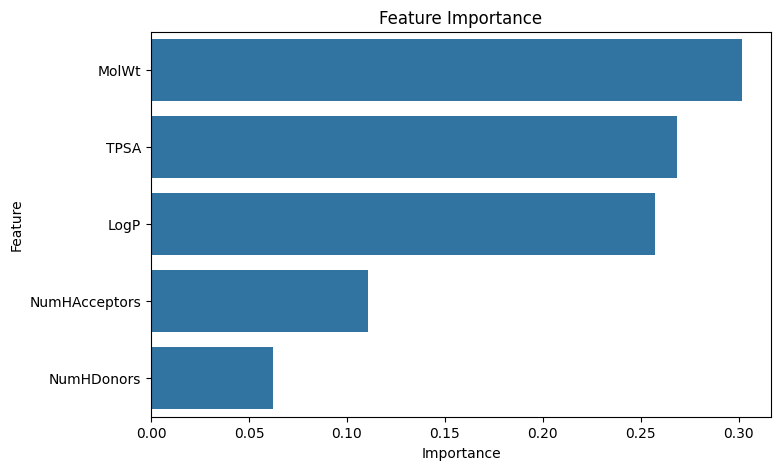

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

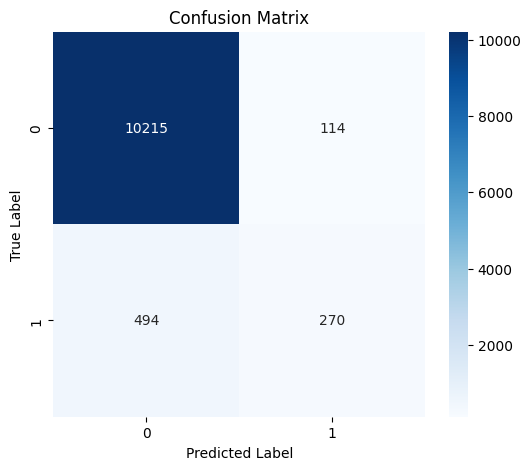

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, best_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

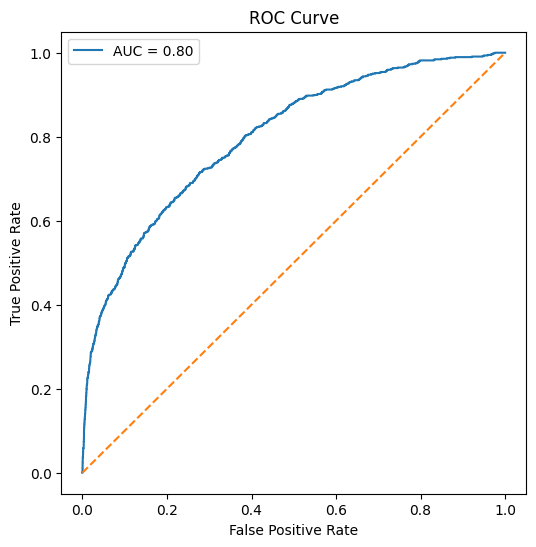

In [ ]:
from sklearn.metrics import roc_curve, auc

# Prediction probabilities
y_probs = xgb_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

The ROC curve demonstrates strong classification capability, while the AUC score summarizes overall model discrimination performance.

In [ ]:
joblib.dump(rf_balanced, 'bioactivity_model.pkl')
joblib.dump(selected_features, 'features.pkl')
# scaler.pkl is NOT needed model was trained on raw unscaled data
print("Assets exported successfully!")

Assets exported successfully!


In [ ]:
!ls

'Bioactive (1).xlsx'   bioactivity_model.pkl   sample_data
 Bioactive.xlsx        features.pkl	       scaler.pkl


In [ ]:
selected_features = [
    'MolWt',
    'LogP',
    'NumHDonors',
    'NumHAcceptors',
    'TPSA'
]

joblib.dump(selected_features, 'features.pkl')

['features.pkl']

In [ ]:
import joblib

joblib.dump(rf_model, "bioactivity_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(features, "features.pkl")

['features.pkl']

In [ ]:
!ls

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("bioactivity_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("🧬 Bioactivity Prediction System")

st.write("Predict whether a compound is biologically active.")

molwt = st.number_input("Molecular Weight", value=300.0)
logp = st.number_input("LogP", value=2.5)
donors = st.number_input("H-Bond Donors", value=1)
acceptors = st.number_input("H-Bond Acceptors", value=4)
tpsa = st.number_input("TPSA", value=75.0)

if st.button("Predict"):

    sample = pd.DataFrame({
        "MolWt": [molwt],
        "LogP": [logp],
        "NumHDonors": [donors],
        "NumHAcceptors": [acceptors],
        "TPSA": [tpsa]
    })

    prediction = model.predict(sample)[0]

    if prediction == 1:
        st.success("Predicted ACTIVE")
    else:
        st.error("Predicted INACTIVE")

Writing app.py


In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt


In [ ]:
!ls

 app.py		       Bioactive.xlsx	       features.pkl	  sample_data
'Bioactive (1).xlsx'   bioactivity_model.pkl   requirements.txt   scaler.pkl


In [ ]:
import pandas as pd
import numpy as np
import joblib

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ── 1. Load & clean dataset ──────────────────────────────────────────────────
df = pd.read_excel('Bioactive (1).xlsx')          # adjust path if needed
df = df.iloc[2:].reset_index(drop=True)

numeric_cols = ['PUBCHEM_ACTIVITY_SCORE', 'LogGI50_M', 'IndnGI50',
                'StddevGI50', 'LogTGI_M', 'IndnTGI', 'StddevTGI']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.drop(columns=['PUBCHEM_ACTIVITY_URL', 'PUBCHEM_ASSAYDATA_COMMENT',
                 'LogGI50_u', 'LogGI50_V', 'LogTGI_u', 'LogTGI_V'],
        inplace=True, errors='ignore')

df = df.drop_duplicates()

numeric_only = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_only:
    df[col] = df[col].fillna(df[col].median())

df = df.dropna(subset=['PUBCHEM_EXT_DATASOURCE_SMILES'])

# ── 2. Compute RDKit descriptors ─────────────────────────────────────────────
df['Molecule'] = df['PUBCHEM_EXT_DATASOURCE_SMILES'].apply(Chem.MolFromSmiles)
df = df[df['Molecule'].notnull()].copy()

df['MolWt']        = df['Molecule'].apply(Descriptors.MolWt)
df['LogP']         = df['Molecule'].apply(Descriptors.MolLogP)
df['NumHDonors']   = df['Molecule'].apply(Lipinski.NumHDonors)
df['NumHAcceptors']= df['Molecule'].apply(Lipinski.NumHAcceptors)
df['TPSA']         = df['Molecule'].apply(Descriptors.TPSA)

# Keep realistic LogP range (same filter as original notebook)
df = df[(df['LogP'] >= -5) & (df['LogP'] <= 8)]

# ── 3. Encode target ─────────────────────────────────────────────────────────
df['Target'] = df['PUBCHEM_ACTIVITY_OUTCOME'].map({'Active': 1, 'Inactive': 0})
df = df.dropna(subset=['Target'])

print("Class distribution:")
print(df['Target'].value_counts())

# ── 4. Features & split ──────────────────────────────────────────────────────
selected_features = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA']

X = df[selected_features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # keeps class ratio in both splits
    random_state=42
)

# ── 5. Scale ─────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 6. Train BALANCED Random Forest ─────────────────────────────────────────
#   class_weight='balanced' automatically compensates for the 93:7 imbalance
#   by weighting Active samples ~13x more during training.
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # <-- THE KEY FIX
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train_scaled, y_train)   # train on SCALED data

# ── 7. Evaluate ──────────────────────────────────────────────────────────────
y_pred = rf_balanced.predict(X_test_scaled)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Inactive', 'Active']))

# ── 8. Export fixed assets ───────────────────────────────────────────────────
joblib.dump(rf_balanced,       'bioactivity_model.pkl')
joblib.dump(scaler,            'scaler.pkl')
joblib.dump(selected_features, 'features.pkl')

print("\nFixed assets saved:")
print("  bioactivity_model.pkl  — balanced Random Forest")
print("  scaler.pkl             — StandardScaler fit on training data")
print("  features.pkl           — ['MolWt','LogP','NumHDonors','NumHAcceptors','TPSA']")

# ── 9. Quick sanity check on the 5 trial compounds ──────────────────────────
print("\nSanity check on trial compounds:")
trials = pd.DataFrame([
    {"label": "A-1 CID 44415057 (Active)",   "MolWt": 1155.46, "LogP": 0.85,  "NumHDonors": 9, "NumHAcceptors": 24, "TPSA": 342.0},
    {"label": "A-2 CID 6197    (Active)",    "MolWt":  253.34, "LogP": 0.62,  "NumHDonors": 3, "NumHAcceptors":  4, "TPSA":  83.9},
    {"label": "A-3 CID 2154    (Active)",    "MolWt":  441.40, "LogP": -1.85, "NumHDonors": 5, "NumHAcceptors": 10, "TPSA": 206.8},
    {"label": "I-1 CID 11122   (Inactive)",  "MolWt":  122.12, "LogP": 0.95,  "NumHDonors": 0, "NumHAcceptors":  2, "TPSA":  34.1},
    {"label": "I-2 CID 219128  (Inactive)",  "MolWt":  364.27, "LogP": 5.32,  "NumHDonors": 0, "NumHAcceptors":  0, "TPSA":   0.0},
])

X_trials = scaler.transform(trials[selected_features])
preds    = rf_balanced.predict(X_trials)
probas   = rf_balanced.predict_proba(X_trials)

for i, row in trials.iterrows():
    result = "ACTIVE" if preds[i] == 1 else "INACTIVE"
    prob   = probas[i][1] * 100
    print(f"  {row['label']:35s} -> {result:8s}  (Active prob: {prob:.1f}%)")

[11:38:41] WARNING: not removing hydrogen atom without neighbors
[11:38:45] WARNING: not removing hydrogen atom without neighbors


Class distribution:
Target
0    51641
1     3821
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

    Inactive       0.95      0.99      0.97     10329
      Active       0.70      0.35      0.47       764

    accuracy                           0.94     11093
   macro avg       0.83      0.67      0.72     11093
weighted avg       0.94      0.94      0.94     11093


Fixed assets saved:
  bioactivity_model.pkl  — balanced Random Forest
  scaler.pkl             — StandardScaler fit on training data
  features.pkl           — ['MolWt','LogP','NumHDonors','NumHAcceptors','TPSA']

Sanity check on trial compounds:
  A-1 CID 44415057 (Active)           -> ACTIVE    (Active prob: 79.5%)
  A-2 CID 6197    (Active)            -> INACTIVE  (Active prob: 0.0%)
  A-3 CID 2154    (Active)            -> INACTIVE  (Active prob: 9.9%)
  I-1 CID 11122   (Inactive)          -> INACTIVE  (Active prob: 0.0%)
  I-2 CID 219128  (Inactive)          -> 

In [ ]:
from google.colab import files
files.download('bioactivity_model.pkl')
files.download('scaler.pkl')
files.download('features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('bioactivity_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>